# Task 10 — Logistic Regression and Evaluation

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("../data/loan_data.csv")
df.dropna(inplace=True)
df = df.drop_duplicates().reset_index(drop=True)
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])


In [5]:

feature_cols = ['age','income','loan_amount','credit_score','employment_years','education']
X = df[feature_cols]
y = df['approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [8]:
model = LogisticRegression()
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['Rejected','Approved']))

Accuracy: 0.9074074074074074

              precision    recall  f1-score   support

    Rejected       0.67      0.33      0.44         6
    Approved       0.92      0.98      0.95        48

    accuracy                           0.91        54
   macro avg       0.79      0.66      0.70        54
weighted avg       0.89      0.91      0.89        54



### Confusion Matrix

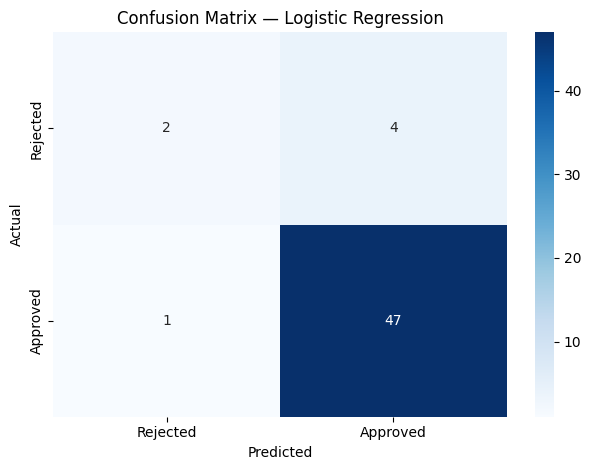

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("logistic_cm.png")
plt.show()